<h1> Causal disovery individual cells

<h2> imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
from scipy.io import loadmat
from Preprocessing.imbalanced_performance.preprocess_new import IndividualProcess, CommonProcesses
from project_methods import ProjectMethods
from pathlib import Path
from causal_discovery.algos.notears import NoTears
import networkx as nx
import hashlib
import os
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ScoreBased.CALM import calm
from causallearn.utils.GraphUtils import GraphUtils
from causal_discovery.algos.notears import NoTears
import matplotlib.image as mpimg

<h2> dataset

In [2]:
groups = [[11, 13, 16, 18, 21], [9, 14], [10, 15], [12], [17], [19], [20], [22], [23]]
cols = ['Step_Index', 'TempData', 'VoltageData', 'CurrentData']
cell_dataset = IndividualProcess.getCellDataset()
print(len(cell_dataset))
multicausaldataset = CommonProcesses.multienvcausaldiscoverydataset(cell_dataset, cols, groups)
multicausaldataset_9_23 = multicausaldataset.dropna()
multicausaldatasetdivided = dict(tuple(multicausaldataset_9_23.groupby("Group")))

39
Original data row 1 has unmapped Step_Index values:
       Step_Index   TempData  VoltageData  CurrentData  Group
0               3  23.430807     4.198263     0.000000    NaN
1               3  23.430807     4.198281     0.000000    NaN
2               3  23.416156     4.198245     0.000000    NaN
3               3  23.416155     4.198041     0.000000    NaN
4               3  23.416155     4.198073     0.000000    NaN
...           ...        ...          ...          ...    ...
70018           8  23.734190     3.242035     2.000053    NaN
70019           8  23.734190     3.242249     2.000072    NaN
70020           8  23.734190     3.242563     2.000072    NaN
70021           8  23.734190     3.242818     2.000072    NaN
70022           8  23.734190     3.242814     2.000073    NaN

[44686 rows x 5 columns]


In [3]:
print(multicausaldataset_9_23.head(10))
print(multicausaldataset_9_23.isnull().sum())

    TempData  VoltageData  CurrentData  Group
0  24.041702     4.197761          0.0    1.0
1  23.955681     4.197635          0.0    1.0
2  23.926302     4.197824          0.0    1.0
3  23.979719     4.197635          0.0    1.0
4  24.001940     4.197635          0.0    1.0
5  24.040009     4.197635          0.0    1.0
6  24.061624     4.197446          0.0    1.0
7  23.975770     4.197572          0.0    1.0
8  23.971016     4.197824          0.0    1.0
9  23.942123     4.197698          0.0    1.0
TempData       0
VoltageData    0
CurrentData    0
Group          0
dtype: int64


<h2> Causal Discovery

<h3> PC-algorithm

In [4]:
labels = [multicausaldataset_9_23.columns]
# Convert to numpy array
data = multicausaldataset_9_23.to_numpy()
print(data.shape)
print(labels)
n_samples = data.shape[0]
n_features = data.shape[1]
pc_result = pc(data)

(2743566, 4)
[Index(['TempData', 'VoltageData', 'CurrentData', 'Group'], dtype='object')]


  0%|          | 0/4 [00:00<?, ?it/s]

In [1]:
pydot_graph_pc = GraphUtils.to_pydot(pc_result.G, labels=labels[0])
pydot_graph_pc.write_png('../Src/structures/1cells_char/images/multienv/pc.png')

NameError: name 'GraphUtils' is not defined

<h3> NoTears-algorithm

<h4> Per Goup

In [6]:
dags = ProjectMethods.NoTearsByGroup(multicausaldatasetdivided, '../Src/structures/1cells_char/images/multienv/NoTears/ByGroup')
print(dags)

100%|██████████| 20/20 [00:06<00:00,  3.08it/s]

{'ad805990b3d464d4babff2fa7d22d3e2': 2, '45bde37720d0ffd473002c39f6b166f7': 3, 'd6134724341c8f5d032badde71f4efa2': 3}


Matrix shape: (3, 3)
Non-zero elements: 5
[[0.    0.    0.375]
 [1.    0.    0.375]
 [0.375 0.375 0.   ]]


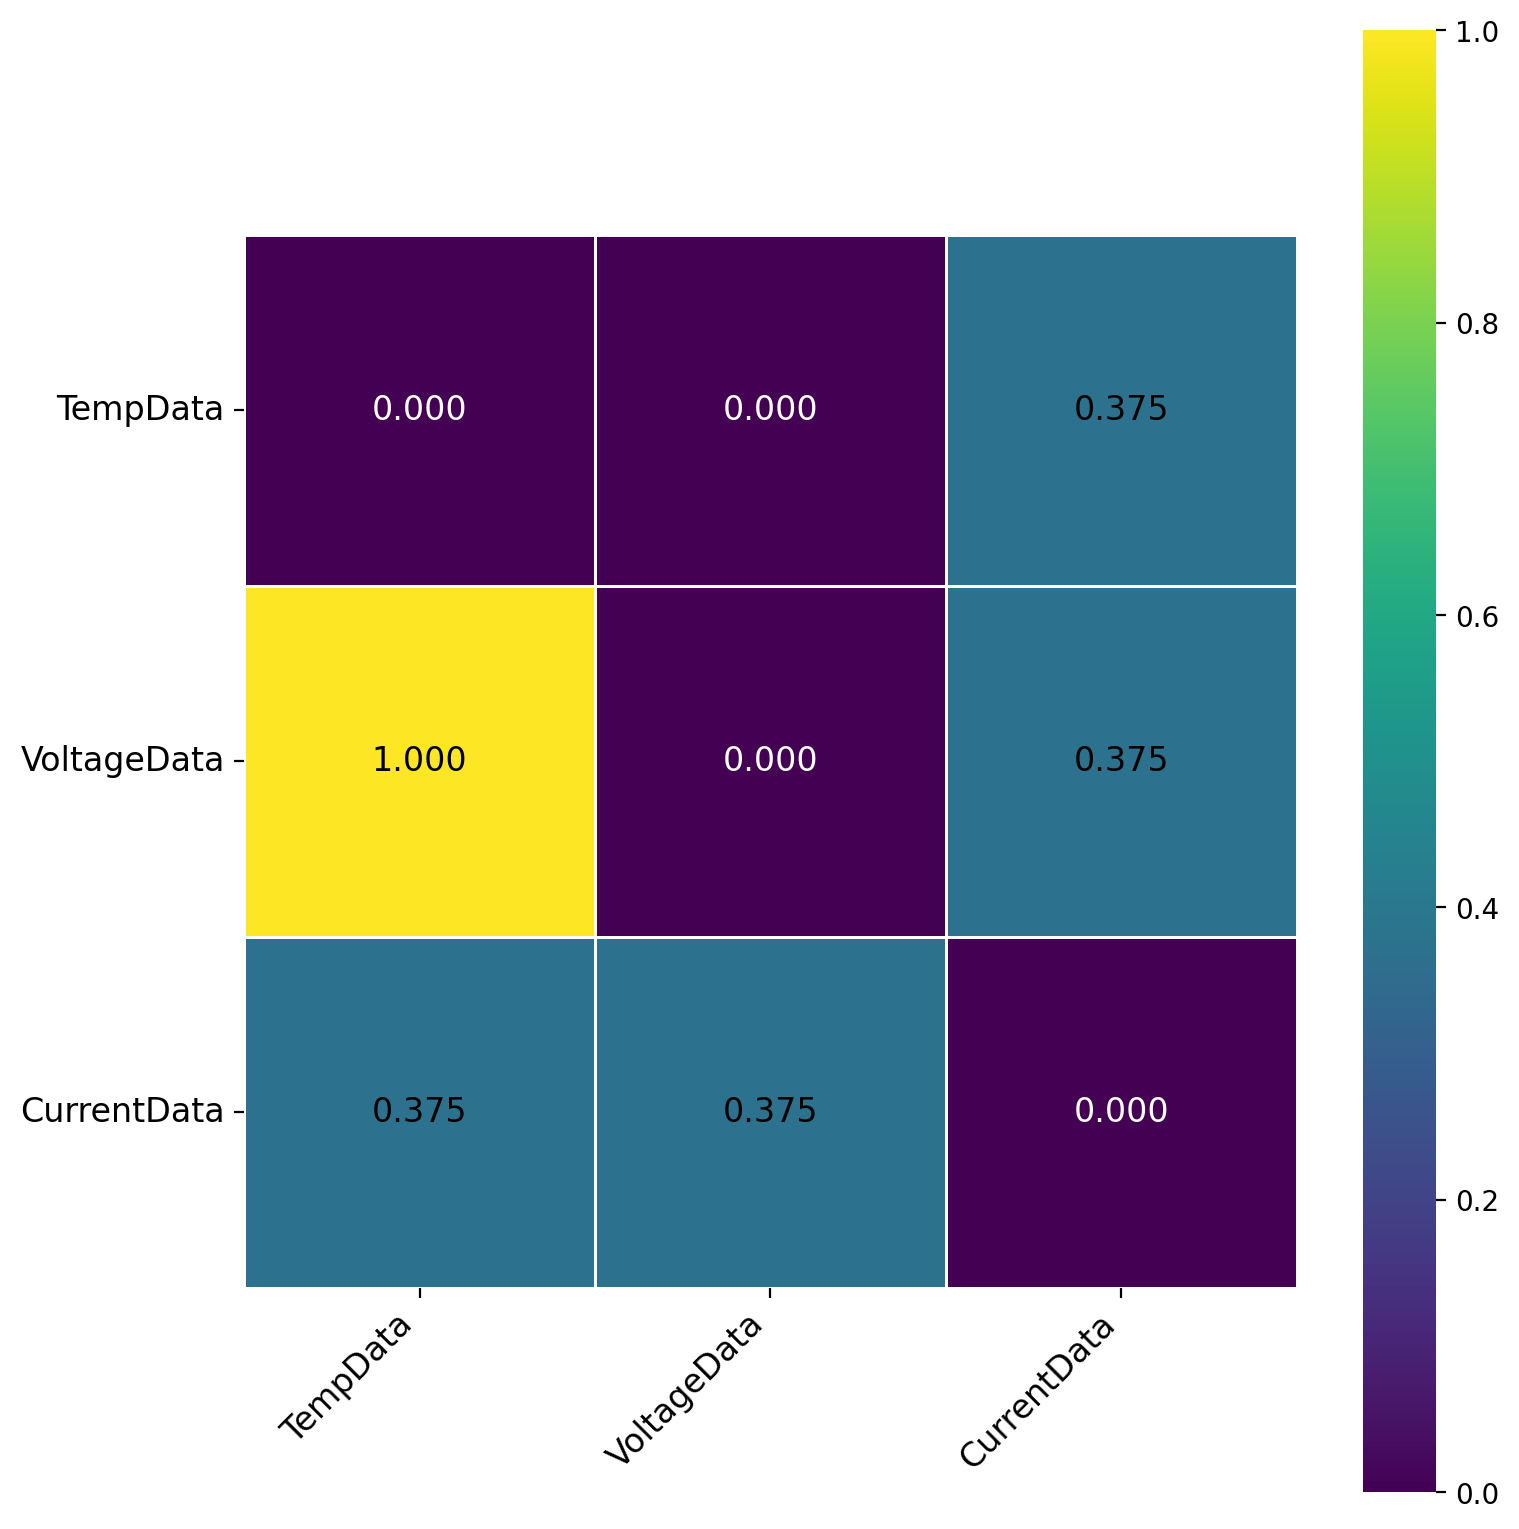

In [7]:
dag_list, cols = ProjectMethods.load_all_dags("../Src/structures/1cells_char/images/multienv/NoTears/ByGroup")           # from saved files
freq_matrix = ProjectMethods.dag_frequency_matrix(dag_list)
print("Matrix shape:", freq_matrix.shape)
print("Non-zero elements:", np.count_nonzero(freq_matrix))
print(freq_matrix)
ProjectMethods.plot_dag_frequency_heatmap(freq_matrix, cols, save_path="../Src/structures/1cells_char/images/multienv/NoTears/ByGroup/edge_frequency_heatmap.png")

<h4> Full-dataset

In [9]:
dags = ProjectMethods.NoTearsLargeDataset(X_full=data, cols=multicausaldataset_9_23.columns.tolist(), save_point='../Src/structures/1cells_char/images/multienv/NoTears/fulldata', subset_size=20000000)
print(dags)

2743566
Running subsample 1/5 (2743566 rows)...


100%|██████████| 20/20 [00:14<00:00,  1.39it/s]


Running subsample 2/5 (2743566 rows)...


100%|██████████| 20/20 [00:15<00:00,  1.32it/s]


Running subsample 3/5 (2743566 rows)...


...

Running subsample 4/5 (2743566 rows)...


100%|██████████| 20/20 [00:14<00:00,  1.40it/s]


Running subsample 5/5 (2743566 rows)...


100%|██████████| 20/20 [00:14<00:00,  1.39it/s]

['TempData', 'VoltageData', 'CurrentData', 'Group']
Saved DAG with threshold 0.3 at ../Src/structures/1cells_char/images/multienv/NoTears/fulldata
[[0 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 1 0 0]]


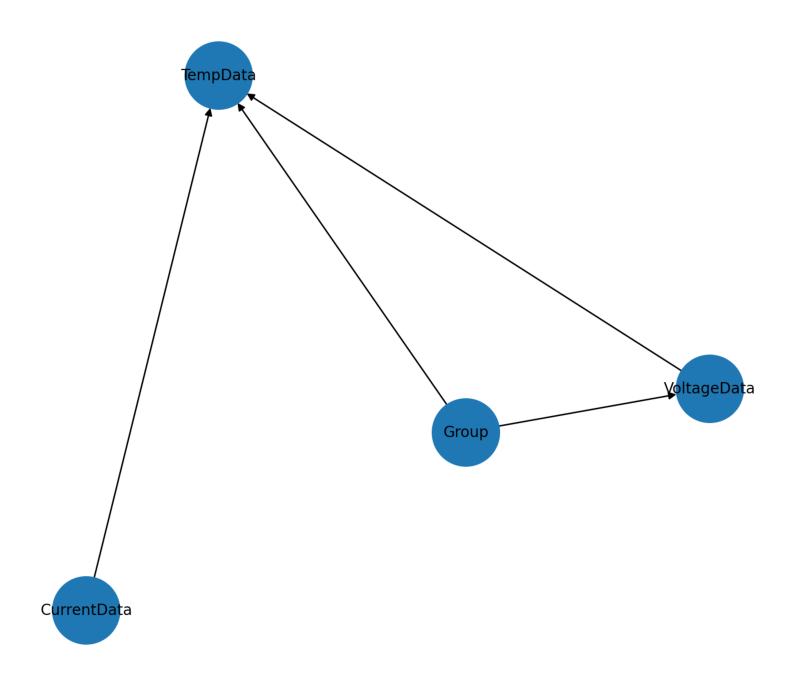

In [10]:
img_path = "../Src/structures/1cells_char/images/multienv/NoTears/fulldata/dag.png"

# Load and show
img = mpimg.imread(img_path)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')  # hide axes
plt.show()

<h3> Third alg

In [ ]:
calm_result = calm(data)


In [ ]:
pydot_graph_calm = GraphUtils.to_pydot(calm_result['G'], labels=labels[0])
pydot_graph_calm.write_png('../Src/structures/1cells_char/images/multienv/calm.png')